In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [8]:
path = r"H:\Python\Terceira Etapa\Jupyter\atv4\CD2022_Populacao_2010_Compatibilizada_20231222.xlsx"

In [12]:
dados = pd.read_excel(path, header=2)

In [16]:
dados

,Unnamed: 0,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
0,NaN,RO,11.0,15.0,Alta Floresta D'Oeste,24392.0,24392.0,21494.0
1,NaN,RO,11.0,23.0,Ariquemes,90353.0,90353.0,96833.0
2,NaN,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,NaN,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,NaN,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0
...,...,...,...,...,...,...,...,...
5569,NaN,DF,53.0,108.0,Brasília,2570160.0,2572159.0,2817381.0
5570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5571,NaN,Nota: Para o cálculo das taxas de crescimento ...,NaN,NaN,NaN,NaN,NaN,NaN
5572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
semi_tratados1 = dados.iloc[0:5574, 1:]

In [18]:
semi_tratados1

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
0,RO,11.0,15.0,Alta Floresta D'Oeste,24392.0,24392.0,21494.0
1,RO,11.0,23.0,Ariquemes,90353.0,90353.0,96833.0
2,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0
...,...,...,...,...,...,...,...
5569,DF,53.0,108.0,Brasília,2570160.0,2572159.0,2817381.0
5570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5571,Nota: Para o cálculo das taxas de crescimento ...,NaN,NaN,NaN,NaN,NaN,NaN
5572,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
semi_tratados1 = semi_tratados1.iloc[0:5570]

In [20]:
semi_tratados1.columns

Index(['UF', 'COD. UF', 'COD. MUNIC', 'NOME DO MUNICÍPIO',
       'População Município 2010\n(Sinopse)',
       'População 2010 (Alterações de Limites até 2022)1',
       'População Censo 2022'],
      dtype='str')

In [21]:
semi_tratados1["Diferenca"] = semi_tratados1['População Censo 2022'] - semi_tratados1['População Município 2010\n(Sinopse)']
        

In [22]:
semi_tratados1.columns

Index(['UF', 'COD. UF', 'COD. MUNIC', 'NOME DO MUNICÍPIO',
       'População Município 2010\n(Sinopse)',
       'População 2010 (Alterações de Limites até 2022)1',
       'População Censo 2022', 'Diferenca'],
      dtype='str')

In [23]:
pop_estado = semi_tratados1.groupby("UF")[['População Município 2010\n(Sinopse)', 'População Censo 2022', 'Diferenca']].sum().reset_index()

In [24]:
pop_estado

,UF,População Município 2010\n(Sinopse),População Censo 2022,Diferenca
0,AC,733559.0,830018.0,96459.0
1,AL,3120494.0,3127683.0,7189.0
2,AM,3483985.0,3941613.0,457628.0
3,AP,669526.0,733759.0,64233.0
4,BA,14016906.0,14141626.0,124720.0
5,CE,8452381.0,8794957.0,342576.0
6,DF,2570160.0,2817381.0,247221.0
7,ES,3514952.0,3833712.0,318760.0
8,GO,6003788.0,7056495.0,1052707.0
9,MA,6574789.0,6776699.0,201910.0


In [25]:

pop_estado.to_csv(r"H:\Python\Terceira Etapa\Jupyter\atv4\PopulacaoPorEstado.csv", sep =";")

KeyError: '2022'

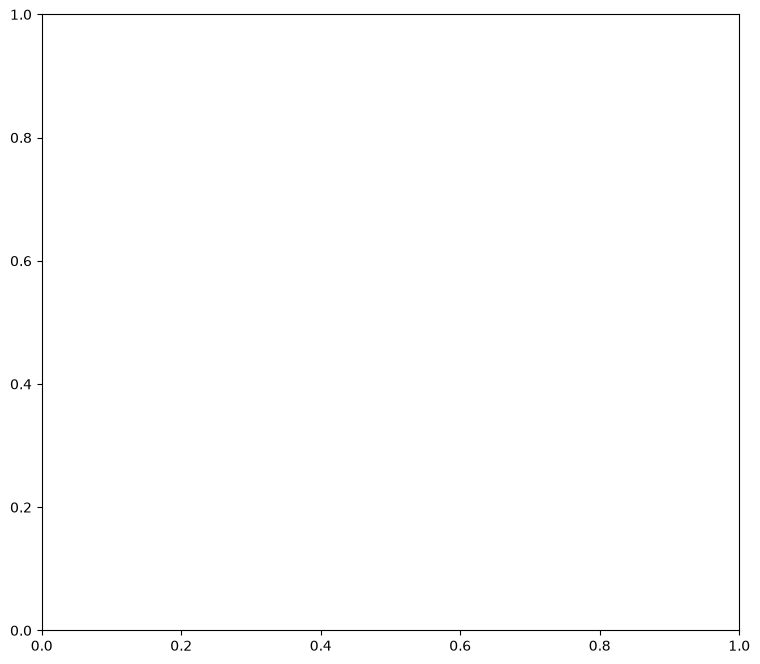

In [33]:
# TODO()
# Barras: população 2022 por UF
fig, ax = plt.subplots(figsize=(9, 8))
ordem = pop_estado.sort_values("2022", ascending=False)
sns.barplot(data=ordem, y="UF", x="2022", ax=ax, color="steelblue")
ax.set_title("População 2022 por UF")
ax.set_xlabel("Habitantes")
ax.set_ylabel("UF")
plt.tight_layout()
plt.show()